In [16]:
import yfinance as yf
import pandas as pd

tickers = ['TSLA', 'BND', 'SPY']

# Set auto_adjust=False to get the 'Adj Close' column back
data = yf.download(tickers, start='2015-01-01', end='2026-01-16', auto_adjust=False)

# Now this will work

adj_close = data['Adj Close']
adj_close.to_csv('../data/processed/tesla_bnd_spy_data.csv')

# Display the first few rows to confirm
print(adj_close.head())

[*********************100%***********************]  3 of 3 completed

Ticker            BND         SPY       TSLA
Date                                        
2015-01-02  60.385971  170.589615  14.620667
2015-01-05  60.561356  167.508820  14.006000
2015-01-06  60.736656  165.931061  14.085333
2015-01-07  60.773228  167.998779  14.063333
2015-01-08  60.678246  170.979919  14.041333


In [5]:
returns = adj_close.pct_change().dropna()

In [6]:
rolling_vol = returns.rolling(window=30).std()

In [7]:
from statsmodels.tsa.stattools import adfuller

def check_stationarity(series):
    result = adfuller(series)
    print(f'ADF Statistic: {result[0]}')
    print(f'p-value: {result[1]}')
    # If p-value > 0.05, the series is non-stationary.

In [8]:
sharpe_ratio = (returns.mean() / returns.std()) * (252**0.5)

In [9]:
var_95 = returns.quantile(0.05)

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate daily percentage change (returns)
returns = adj_close.pct_change().dropna()

# Set a professional style for the plots
sns.set_theme(style="whitegrid")

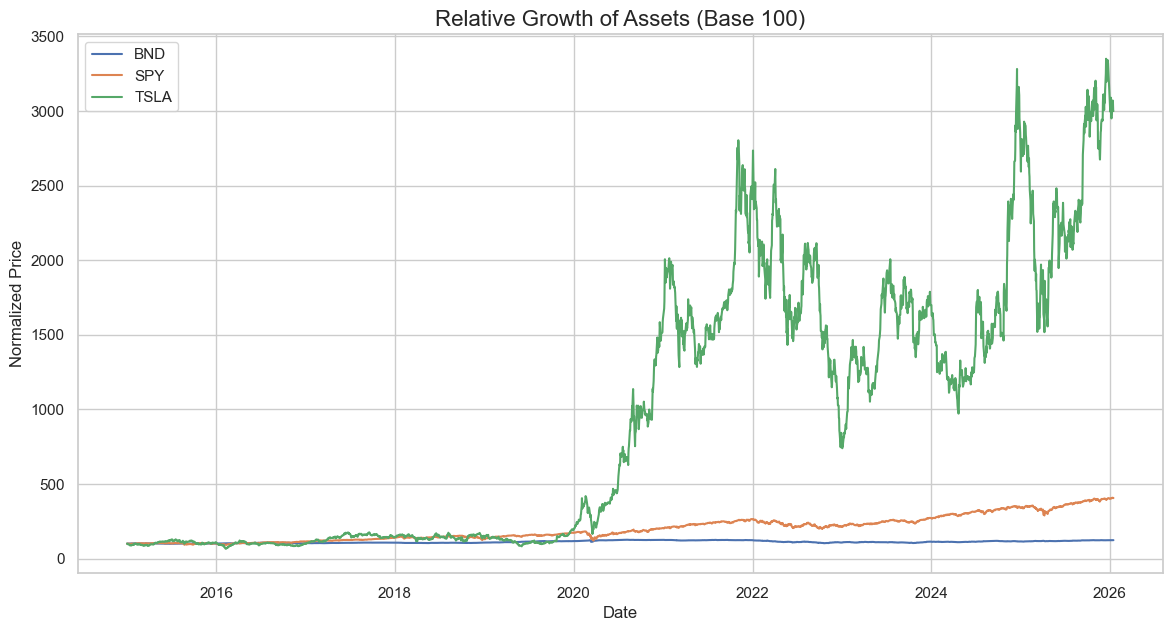

In [11]:
plt.figure(figsize=(14, 7))

# Normalize the prices: (Price / First Price) * 100
normalized_prices = (adj_close / adj_close.iloc[0]) * 100

for ticker in normalized_prices.columns:
    plt.plot(normalized_prices.index, normalized_prices[ticker], label=ticker)

plt.title('Relative Growth of Assets (Base 100)', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Normalized Price')
plt.legend()
plt.show()

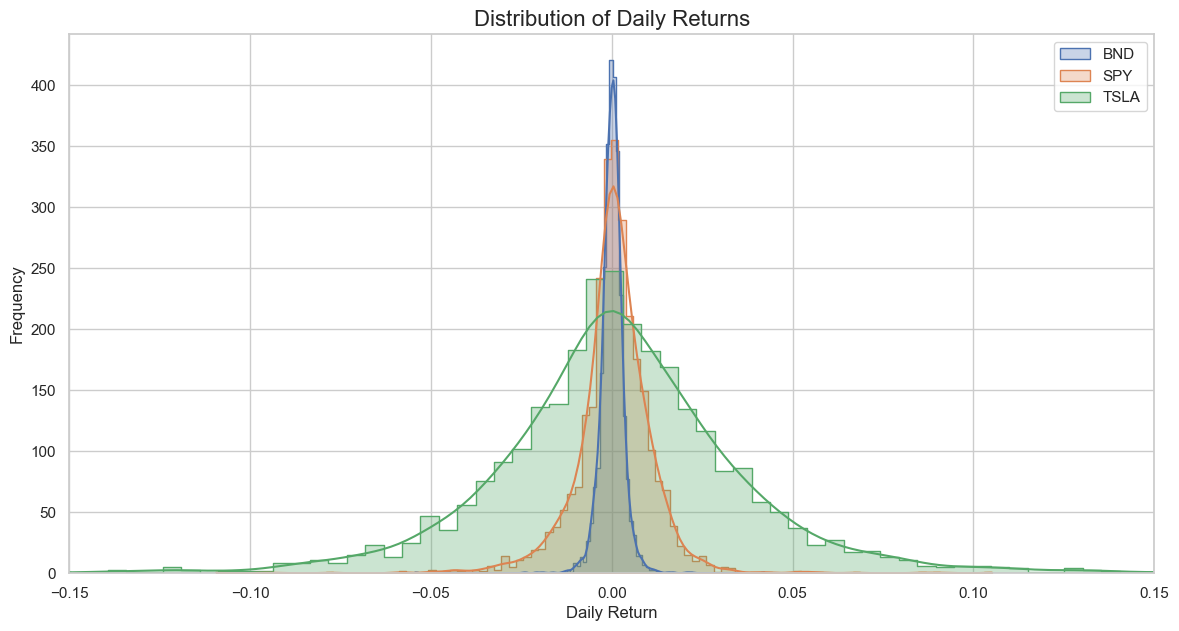

In [12]:
plt.figure(figsize=(14, 7))

# Plotting the distribution of returns for each asset
for ticker in returns.columns:
    sns.histplot(returns[ticker], kde=True, label=ticker, element="step", alpha=0.3)

plt.title('Distribution of Daily Returns', fontsize=16)
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.xlim(-0.15, 0.15) # Zoom in to see the bulk of the data
plt.legend()
plt.show()

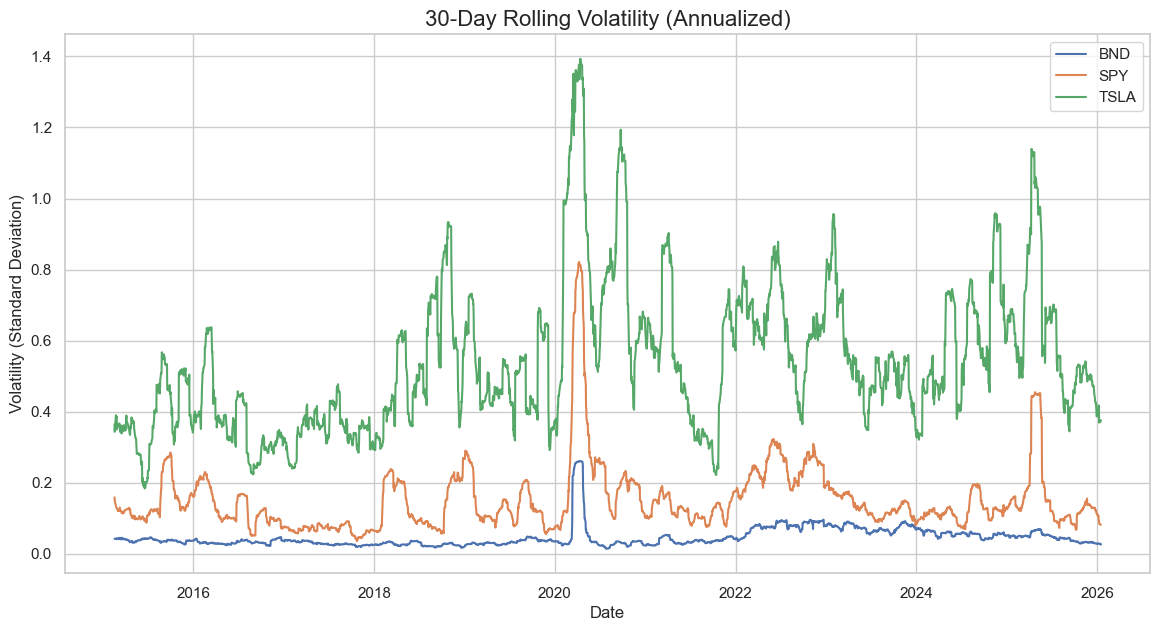

In [13]:
plt.figure(figsize=(14, 7))

# Calculate 30-day rolling standard deviation (annualized)
# Multiply by sqrt(252) to convert daily volatility to annual volatility
rolling_vol = returns.rolling(window=30).std() * (252**0.5)

for ticker in rolling_vol.columns:
    plt.plot(rolling_vol.index, rolling_vol[ticker], label=ticker)

plt.title('30-Day Rolling Volatility (Annualized)', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Volatility (Standard Deviation)')
plt.legend()
plt.show()

In [14]:
from statsmodels.tsa.stattools import adfuller

def perform_adf_test(series, name):
    print(f"--- ADF Test for {name} ---")
    result = adfuller(series.dropna())
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    if result[1] <= 0.05:
        print("Result: Stationary (Reject Null Hypothesis)")
    else:
        print("Result: Non-Stationary (Fail to Reject Null Hypothesis)")
    print("-" * 30)

# Test raw prices (usually non-stationary)
perform_adf_test(adj_close['TSLA'], "TSLA Adjusted Close Price")

# Test daily returns (usually stationary)
perform_adf_test(returns['TSLA'], "TSLA Daily Returns")

--- ADF Test for TSLA Adjusted Close Price ---
ADF Statistic: -0.7832
p-value: 0.8240
Result: Non-Stationary (Fail to Reject Null Hypothesis)
------------------------------
--- ADF Test for TSLA Daily Returns ---
ADF Statistic: -53.0309
p-value: 0.0000
Result: Stationary (Reject Null Hypothesis)
------------------------------


In [15]:
import numpy as np

# 1. Sharpe Ratio (Annualized) - Assuming risk-free rate is 0 for simplicity
sharpe_ratios = (returns.mean() / returns.std()) * np.sqrt(252)

# 2. Value at Risk (VaR) at 95% confidence level
var_95 = returns.quantile(0.05)

print("--- Risk Metrics ---")
for ticker in tickers:
    print(f"{ticker}: Sharpe Ratio = {sharpe_ratios[ticker]:.4f}, VaR (95%) = {var_95[ticker]:.4f}")

--- Risk Metrics ---
TSLA: Sharpe Ratio = 0.8228, VaR (95%) = -0.0525
BND: Sharpe Ratio = 0.3789, VaR (95%) = -0.0048
SPY: Sharpe Ratio = 0.8052, VaR (95%) = -0.0167
